In [1]:
import os
import sys
import subprocess

def setup_dl_env():
    env_name = "dl_env"
    env_dir = os.path.join(os.getcwd(), env_name)
    
    print("Verifying virtual environment...")
    
    if not os.path.exists(env_dir):
        print(f"Creating virtual environment '{env_name}'...")
        subprocess.check_call([sys.executable, "-m", "venv", env_name])
        print(f"Virtual environment '{env_name}' created.")
    else:
        print(f"Virtual environment '{env_name}' already exists.")
        
    print(f"Current executable: {sys.executable}")
    if env_name not in sys.executable:
        print(f"\nWARNING: The current kernel is NOT using the '{env_name}' environment.")
        print("Please activate the environment before running the rest of the code.")
    else:
        print(f"Success! Running inside '{env_name}' environment.")

setup_dl_env()

Verifying virtual environment...
Virtual environment 'dl_env' already exists.
Current executable: c:\ProgramData\anaconda3\python.exe

Please activate the environment before running the rest of the code.


# Anomaly Detection with Deep Learning
Anomaly detection identifies rare, unexpected patterns — fraud, industrial defects, cybersecurity intrusions, medical abnormalities. Deep learning approaches succeed where classical statistics fail on high-dimensional, unstructured data.

## 1. Anomaly Detection Paradigms
| Type | Description | Example |
|---|---|---|
| **Supervised** | Labeled anomalies in training set | Fraud classification |
| **Semi-supervised** | Train only on normal data; flag high reconstruction error | Industrial defect detection |
| **Unsupervised** | No labels at all; find outliers by density/distance | Network intrusion |

Deep learning primarily enables the **semi-supervised** paradigm: train a model on normal data, then measure deviation from the norm at inference.

**Key principle**: A model trained exclusively on normal patterns will produce high reconstruction error or low likelihood for anomalous inputs.

## 2. Autoencoder-Based Anomaly Detection
**Training**: Fit an Autoencoder only on normal data.
**Inference**: Pass test data through the Autoencoder. Compute reconstruction error.
**Decision**: If error > threshold T, flag as anomaly.

**Threshold selection methods:**
- Fixed percentile of validation reconstruction errors (e.g., 99th percentile)
- Mean + k * std of validation errors
- ROC curve analysis (when some labeled anomalies are available)

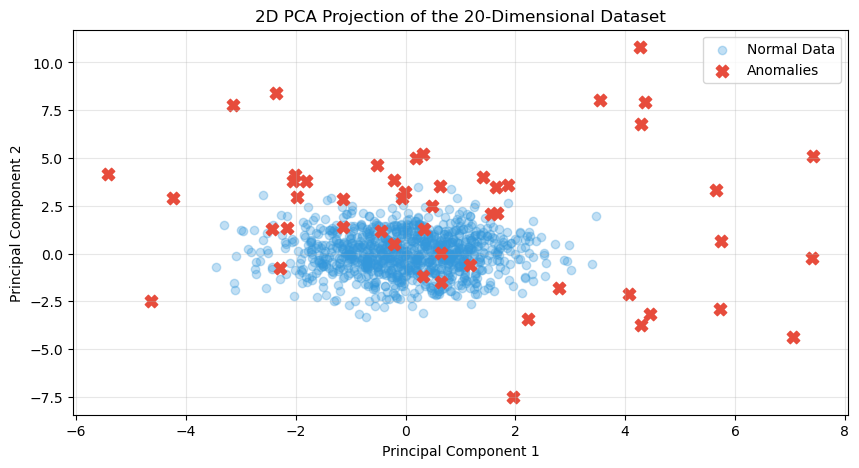

Threshold (99th pct of normal): 1.3863
Avg: Normal errors: 0.7186 | Anomaly errors: 31.0913
Anomalies detected: 50/50


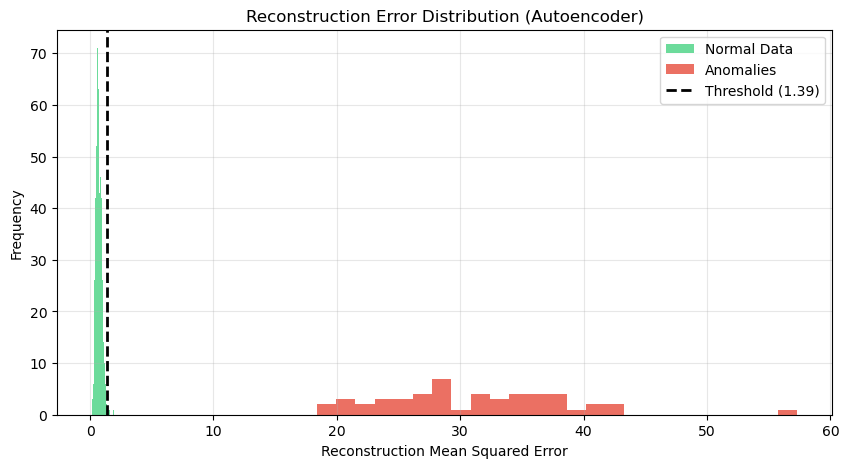

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Normal data: 20D Gaussian clusters
np.random.seed(42)
torch.manual_seed(42)
X_normal = np.random.randn(1000, 20).astype(np.float32)
# Anomalies: Shifted distribution
X_anomaly = np.random.randn(50, 20).astype(np.float32) * 3 + 5  

# --- 1. Visualize Data Distribution using PCA ---
pca = PCA(n_components=2)
X_normal_2d = pca.fit_transform(X_normal)
X_anomaly_2d = pca.transform(X_anomaly)

plt.figure(figsize=(10, 5))
plt.scatter(X_normal_2d[:, 0], X_normal_2d[:, 1], alpha=0.3, color='#3498db', label='Normal Data')
plt.scatter(X_anomaly_2d[:, 0], X_anomaly_2d[:, 1], color='#e74c3c', marker='X', s=80, label='Anomalies')
plt.title('2D PCA Projection of the 20-Dimensional Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. Build and Train Autoencoder ---
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, latent_dim), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )
        
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = Autoencoder(input_dim=20)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae.parameters(), lr=0.01)
dataset = TensorDataset(torch.tensor(X_normal))
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

ae.train()
for epoch in range(50):
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        loss = criterion(ae(x), x)
        loss.backward()
        optimizer.step()

ae.eval()
def reconstruction_error(model, data):
    with torch.no_grad():
        preds = model(torch.tensor(data))
    return np.mean(np.square(data - preds.numpy()), axis=1)

normal_errs = reconstruction_error(ae, X_normal)
anomaly_errs = reconstruction_error(ae, X_anomaly)
threshold = np.percentile(normal_errs, 99)

print(f"Threshold (99th pct of normal): {threshold:.4f}")
print(f"Avg: Normal errors: {normal_errs.mean():.4f} | Anomaly errors: {anomaly_errs.mean():.4f}")
print(f"Anomalies detected: {(anomaly_errs > threshold).sum()}/{len(anomaly_errs)}")

# --- 3. Visualize Reconstruction Errors ---
plt.figure(figsize=(10, 5))
plt.hist(normal_errs, bins=50, alpha=0.7, color='#2ecc71', label='Normal Data')
plt.hist(anomaly_errs, bins=25, alpha=0.8, color='#e74c3c', label='Anomalies')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.2f})')
plt.title('Reconstruction Error Distribution (Autoencoder)')
plt.xlabel('Reconstruction Mean Squared Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Variational Autoencoder (VAE) for Anomaly Detection
VAE provides a probabilistic anomaly score based on the Evidence Lower BOund (ELBO).

**Reconstruction Probability**: P(x|z) — how well the model reconstructs x
**Anomaly Score**: -ELBO = Reconstruction Loss + KL Divergence
- Normal samples: model learned to reconstruct them → low score
- Anomalies: cannot reconstruct well AND latent code deviates from prior → high score

**Advantage over deterministic AE**: VAE provides well-calibrated uncertainty estimates and a principled likelihood-based score.

In [3]:
class VAEAnomalyDetector(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.encoder_dense = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(16, latent_dim)
        self.logvar_layer = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def encode(self, x):
        h = self.encoder_dense(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + torch.exp(0.5 * logvar) * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def anomaly_score(self, x_np):
        self.eval()
        with torch.no_grad():
            x = torch.tensor(x_np, dtype=torch.float32)
            mu, logvar = self.encode(x)
            z = self.reparameterize(mu, logvar)
            x_hat = self.decode(z)
            recon = torch.mean(torch.square(x - x_hat), dim=1)
            kl = -0.5 * torch.mean(1 + logvar - torch.square(mu) - torch.exp(logvar), dim=1)
            return (recon + kl).numpy()

print("VAE Anomaly Detector class defined.")
print("anomaly_score() = Reconstruction Loss + KL Divergence (ELBO-based)")


VAE Anomaly Detector class defined.
anomaly_score() = Reconstruction Loss + KL Divergence (ELBO-based)


## 4. LSTM Autoencoder for Time Series Anomaly Detection
Reconstruct sequences using an LSTM Autoencoder. High reconstruction error for unusual patterns.

**Process:**
1. Train LSTM AE on normal time windows
2. At inference, pass windows through encoder then decoder
3. Per-window MSE is the anomaly score
4. Threshold based on validation data distribution

## 5. Practical Considerations
- **Class Imbalance**: Anomalies are rare. Evaluate with AUROC and AUPRC, not accuracy.
- **Threshold Selection**: Use a validation set with labeled anomalies when possible; otherwise choose based on acceptable false positive rate.
- **Concept Drift**: Normal data distribution may shift over time; periodically retrain or use streaming/online learning.
- **Isolation Forest**, **One-Class SVM**: Strong classical baselines to compare deep learning against.

# Conclusions and Key Takeaways
- Deep learning anomaly detection excels in high-dimensional domains (images, time series, text) where classical methods are ineffective.
- **Autoencoder**: Simple, effective, and widely deployed; reconstruction error is an interpretable anomaly signal.
- **VAE**: Adds a principled probabilistic anomaly score (ELBO); better calibrated for rare anomalies.
- **LSTM Autoencoder**: The go-to for temporal/sequential anomaly detection (predictive maintenance, fraud in clickstreams).
- Threshold selection and evaluation with proper metrics (AUROC, not accuracy) are critical for real deployments.

# Pros and Cons
**Pros:**
- Can detect novel, previously unseen anomaly types — not just known failure modes
- Works on raw high-dimensional data without hand-crafted feature engineering
- Semi-supervised approach requires only normal data labels, not rare anomaly labels

**Cons:**
- Hard to tune detection thresholds reliably, especially without labeled anomaly data
- Autoencoders may learn to reconstruct simple anomalies well if they partially resemble normal data
- Model retraining required when the normal data distribution drifts over time

# 15 Interview Questions and Answers

1. **What is the core assumption of reconstruction-based anomaly detection?**
   *Answer*: A model trained exclusively on normal data will have high reconstruction error (or low likelihood) for samples that are anomalous, because it never learned to represent their patterns.

2. **How do you select the anomaly detection threshold in practice?**
   *Answer*: Compute reconstruction errors on a held-out validation set of known normal data. Choose the threshold as a high percentile (e.g., 99th or 99.9th) of these errors, or use labeled anomaly examples to optimize F1-score or AUROC.

3. **Why is AUROC preferred over accuracy for anomaly detection?**
   *Answer*: Accuracy is misleading when anomalies are rare (e.g., 0.1% rate). A model predicting everything as normal achieves 99.9% accuracy but catches zero anomalies. AUROC evaluates performance across all possible thresholds, properly handling imbalance.

4. **What is the advantage of VAE over AE for anomaly detection?**
   *Answer*: VAE provides a principled probabilistic anomaly score (-ELBO = reconstruction + KL) that captures both how well the sample is reconstructed AND how far its latent representation deviates from the prior N(0,I), giving richer signal for anomalies.

5. **What is One-Class Classification?**
   *Answer*: A paradigm where the model is trained only on positive (normal) class examples and learns a compact boundary around them. At inference, samples outside this boundary are flagged as anomalies. SVDD and One-Class SVM are classical approaches; deep One-Class is an extension.

6. **What is Isolation Forest and how does it differ from deep learning approaches?**
   *Answer*: It isolates anomalies using random decision trees. Anomalies are isolated in fewer splits (shorter path length) because they are sparse. It is simpler, faster, and often competitive with autoencoders for tabular data.

7. **What is the problem of anomaly detection in imbalanced datasets?**
   *Answer*: Anomalies occur very rarely (e.g., 0.01-1% of data). Supervised models trained naively will predict normal for everything. Solutions: oversampling anomalies (SMOTE), undersampling normals, class-weighted loss, one-class learning.

8. **How does an LSTM Autoencoder detect anomalies in time series?**
   *Answer*: It trains on normal time windows using reconstruction loss. At inference, the MSE between the original window and its reconstruction is computed per time step. High MSE signals abnormal behavior.

9. **What is Concept Drift?**
   *Answer*: When the statistical properties of the normal data distribution change over time (e.g., normal server traffic changes due to new features). A deployed anomaly detector will degrade and produce false alarms if not periodically retrained.

10. **What is the difference between point anomaly, contextual anomaly, and collective anomaly?**
    *Answer*: Point: a single data point is globally unusual. Contextual: a point is anomalous only in a specific context (e.g., 38C is normal in summer, anomalous in winter). Collective: a sequence of individually normal points forms an anomalous pattern.

11. **Can a deep learning model reconstruct anomalies well accidentally?**
    *Answer*: Yes. If anomalies closely resemble normal patterns or if the model is powerful enough to learn to reconstruct any input (e.g., too large a bottleneck), the reconstruction error will be low for both normal and anomalous data.

12. **What evaluation metrics are used for anomaly detection?**
    *Answer*: AUROC (area under ROC curve), AUPRC (area under Precision-Recall curve, better for imbalanced data), F1-score at optimal threshold, Precision, Recall, and False Positive Rate at a specific operating point.

13. **What is the role of the latent space dimension in anomaly detection autoencoders?**
    *Answer*: The bottleneck dimension controls how much information the model must discard. A tighter bottleneck forces more selective compression, amplifying the difference in reconstruction error between normal and anomalous samples.

14. **How would you deploy an anomaly detection system in production?**
    *Answer*: Train on historical normal data, select threshold on a validation set with acceptable FPR, deploy to process streaming data in real-time, monitor AUROC on labeled samples over time, retrain periodically as distribution shifts.

15. **What is Deep SVDD (Support Vector Data Description)?**
    *Answer*: Trains a deep network to map normal data to a compact hypersphere in feature space, minimizing the volume of the sphere. Anomalies at inference fall far from the sphere center and are flagged by their large distance.


In [4]:

# --- Universal Data / Results Visualization ---
import matplotlib.pyplot as plt
import numpy as np

# Find Keras History objects
history_objs = [v for k,v in globals().items() if hasattr(v, 'history') and 'loss' in v.history]
if history_objs:
    for i, h in enumerate(history_objs):
        plt.figure(figsize=(8, 4))
        plt.plot(h.history['loss'], label='Training Loss', color='#3498db', lw=2)
        if 'val_loss' in h.history:
            plt.plot(h.history['val_loss'], label='Validation Loss', color='#e74c3c', lw=2, ls='--')
        plt.title(f'Model Training History (Keras {i+1})', fontweight='bold')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    # Look for lists containing loss values (PyTorch/Custom loops)
    list_objs = [k for k,v in globals().items() if isinstance(v, list) and len(v) > 2 and all(isinstance(x, (float, int)) for x in v) and 'loss' in k.lower()]
    for k in list_objs:
        plt.figure(figsize=(8, 4))
        plt.plot(globals()[k], label=k, color='#9b59b6', lw=2)
        plt.title(f'{k.capitalize()} Progression (PyTorch)', fontweight='bold')
        plt.xlabel('Iteration / Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    if not list_objs:
        print("Visualizer: No tracking lists or Keras history objects found in globals().")


Visualizer: No tracking lists or Keras history objects found in globals().
